In [ ]:
#pip install pandas numpy matplotlib plotly seaborn country_converter

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import country_converter as coco


In [2]:
try:
    df_movies = pd.read_csv("clean_datasets/df_movies.csv")
    df_actors = pd.read_csv("clean_datasets/df_actors.csv")
    df_countries = pd.read_csv("clean_datasets/df_countries.csv")
    df_crew = pd.read_csv("clean_datasets/df_crew.csv")
    df_genres = pd.read_csv("clean_datasets/df_genres.csv")
    df_languages = pd.read_csv("clean_datasets/df_languages.csv")
    df_posters = pd.read_csv("clean_datasets/df_posters.csv")
    df_releases = pd.read_csv("clean_datasets/df_releases.csv")
    df_studios = pd.read_csv("clean_datasets/df_studios.csv")
    df_themes = pd.read_csv("clean_datasets/df_themes.csv")

    df_tomatoes = pd.read_csv("clean_datasets/df_tomatoes.csv")
    df_oscars = pd.read_csv("clean_datasets/df_oscars.csv")
except Exception as e:
    print(e)

## Title
3 analisi mirate a capire il successo di un film

## Analysis 1
(Your text here...)

In [3]:
df_movies.dtypes

name            object
date             int64
minute         float64
id_film          int64
tagline         object
description     object
rating         float64
dtype: object

In [4]:
# Create a working copy to avoid messing up the original
df_trend = df_movies.copy()

#Ensure date is numeric and drop weird future dates or extremely old data with few movies
df_trend = df_trend[ (df_trend['date'] >= 1920) & (df_trend['date'] <= 2024) ]
df_trend['date'] = df_trend['date'].astype(int)

# Group by Year and calculate averages for Duration and Rating
yearly_stats = df_trend.groupby('date')[['minute', 'rating']].mean()

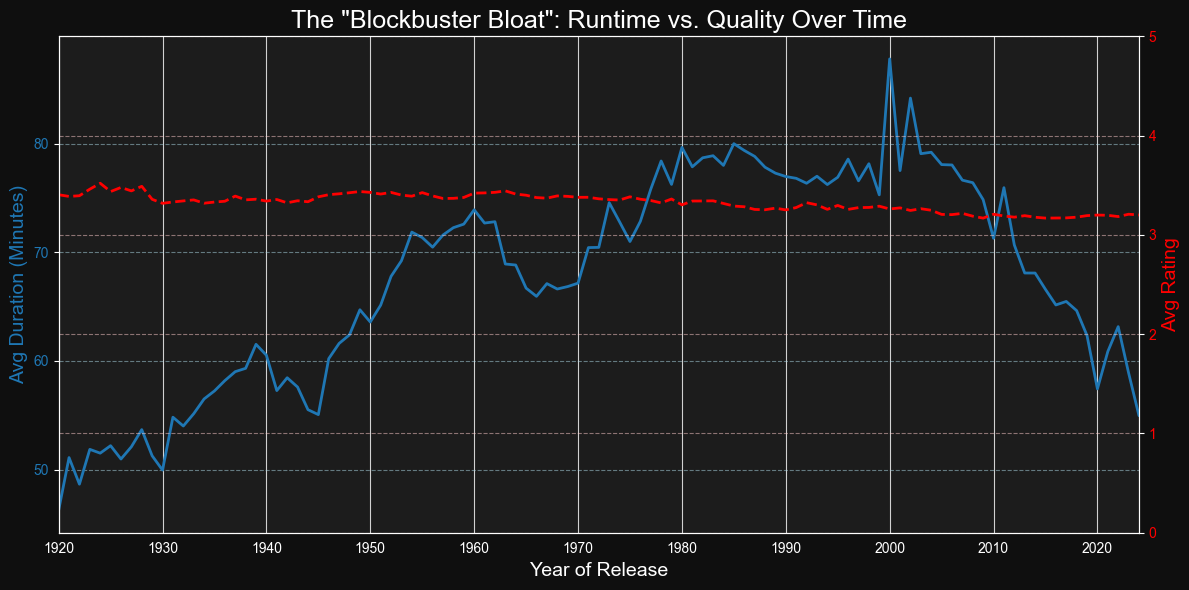

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 6))

plt.plot()
# --- Left Axis: Duration (Blue Line) ---
ax1.set_xlabel('Year of Release', fontsize=14)
ax1.set_ylabel('Avg Duration (Minutes)', color='#1f77b4', fontsize=14)
ax1.plot(yearly_stats.index, yearly_stats['minute'], color='#1f77b4', linewidth=2, label='Duration')
ax1.set_xlim(1920, 2024)
ax1.set_xticks(np.arange(1920, 2024, 10))

ax1.tick_params(axis='y', labelcolor='#1f77b4')
#Vertical Lines: Solid White
ax1.xaxis.grid(True, color='white', linestyle='-', alpha=0.8)
ax1.yaxis.grid(True, color='lightblue', linestyle='--', alpha=0.5)

fig.patch.set_facecolor('#0F0F0F')
ax1.set_facecolor('#1C1C1C')

# --- Right Axis: Rating (Red Line) ---
ax2 = ax1.twinx()
# UPDATED: Label now says 1-5
ax2.set_ylabel('Avg Rating', color='red', fontsize=14)
ax2.plot(yearly_stats.index, yearly_stats['rating'], color='red', linewidth=2, linestyle='--', label='Rating')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.grid(True, color='#ffcccc', linestyle='--', alpha=0.5)

ax2.set_ylim(0, 5)

# Title & Layout
plt.title('The "Blockbuster Bloat": Runtime vs. Quality Over Time', fontsize=18, color='white')
fig.tight_layout()

plt.show()


risultati

## analysi due

In [16]:
df_map_data = pd.merge(
    df_countries[['id_film', 'country']],
    df_movies[['id_film', 'rating']],
    on='id_film'
)

country_means = df_map_data.groupby('country')['rating'].agg(['mean', 'count']).reset_index()

country_means.columns = ['country', 'rating', 'Movie_Count']

cc = coco.CountryConverter()
country_means['iso'] = cc.convert(names=country_means['country'], to='ISO3')

fig = px.choropleth(
    country_means,
    locations="iso",    # Use the name column
    locationmode="ISO-3", # Tell Plotly these are names, not codes
    color="rating",
    hover_name="country",
    color_continuous_scale="Viridis",
    title="Average Movie Rating by Country"
)

fig.show()

East Germany not found in regex
Netherlands Antilles not found in regex
Serbia and Montenegro not found in regex
USSR not found in regex
Yugoslavia not found in regex


## analisu 3

## ANALISI $

>>> WINNERS FOUND: 86 <<<


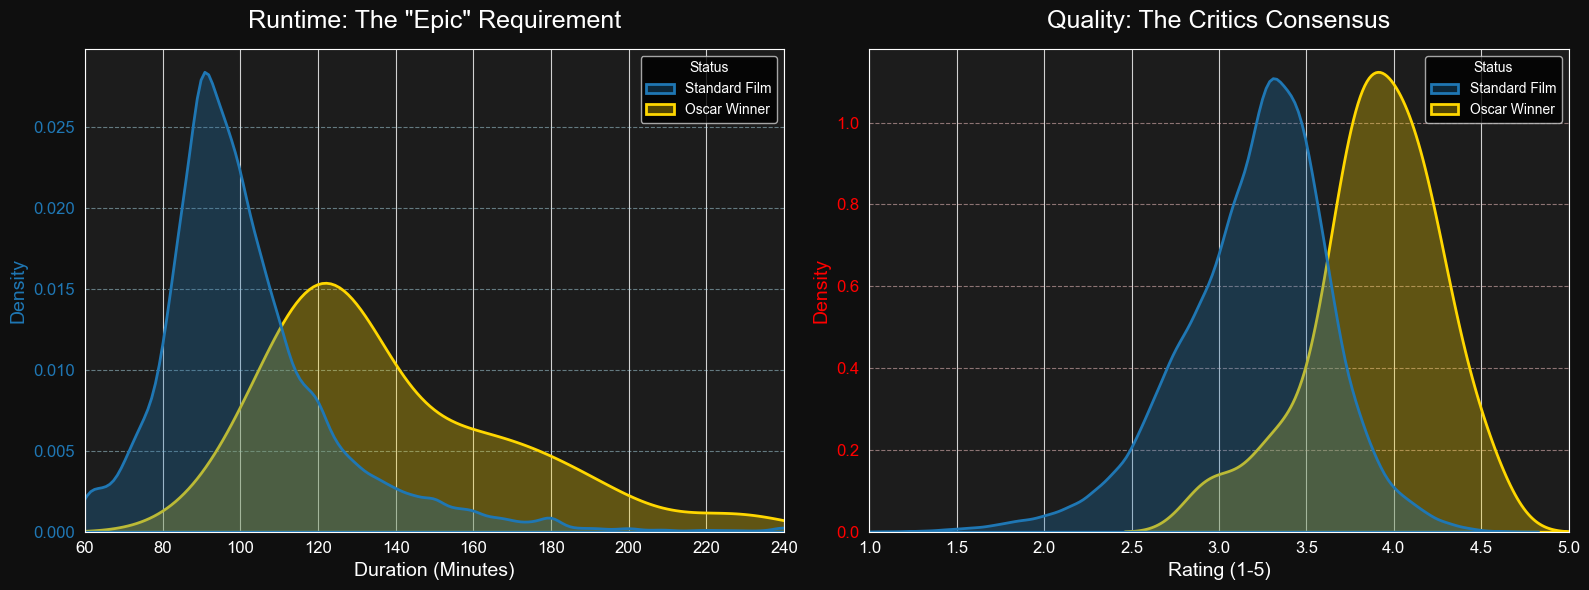

In [7]:
# --- STEP 1: PREPARE OSCAR DATA (Best Picture Only) ---
best_picture_categories = [
    'BEST PICTURE', 'BEST MOTION PICTURE', 'OUTSTANDING PICTURE',
    'OUTSTANDING PRODUCTION', 'OUTSTANDING MOTION PICTURE',
    'UNIQUE AND ARTISTIC PICTURE'
]

# Filter for winners in the top categories
df_bp_winners = df_oscars[
    (df_oscars['category'].isin(best_picture_categories)) &
    (df_oscars['winner'] == True)
][['film', 'year_film', 'winner']]

# Rename columns to match your main movie dataset
df_bp_winners = df_bp_winners.rename(columns={
    'film': 'name',
    'year_film': 'date',
    'winner': 'won_best_picture'
})

# Force Year to Integer for strict matching
df_bp_winners['date'] = df_bp_winners['date'].astype(int)

# --- STEP 2: MERGE WITH MOVIE DATA ---
# Ensure movie dates are integers (handling NaNs safely)
df_trend['date'] = df_trend['date'].fillna(0).astype(int)

# Strict Merge: Match Name AND Year (prevents remix/remake errors)
df_final = pd.merge(df_trend, df_bp_winners, on=['name', 'date'], how='left')

# Fill NaNs: If it didn't match a winner record, it's a "Standard Film" (0)
df_final['won_best_picture'] = df_final['won_best_picture'].fillna(0).astype(int)

# DIAGNOSTIC: Check how many winners we actually found
print(f">>> WINNERS FOUND: {df_final['won_best_picture'].sum()} <<<")

# --- STEP 3: FILTERING & CLEANING ---
# We filter out short films (<60m) and unrated movies to remove "noise"
df_clean = df_final[
    (df_final['minute'] >= 60) &
    (df_final['minute'] <= 240) &
    (df_final['rating'].notna())
].copy()

# Map labels for the Legend
df_clean['Status'] = df_clean['won_best_picture'].map({1: 'Oscar Winner', 0: 'Standard Film'})

# --- STEP 4: VISUALIZATION (Dark Mode Style) ---
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Background Styling
fig.patch.set_facecolor('#0F0F0F') # Outer Background

# 2. Color Palette
my_palette = {'Oscar Winner': '#FFD700', 'Standard Film': '#1f77b4'} # Gold vs Blue

# --- PLOT A: DURATION (Left) ---
ax1 = axes[0]
ax1.set_facecolor('#1C1C1C') # Inner Plot Background

sns.kdeplot(
    data=df_clean,
    x='minute',
    hue='Status',
    palette=my_palette,
    fill=True,
    common_norm=False,
    alpha=0.3,
    linewidth=2,
    warn_singular=False,
    ax=ax1
)

ax1.set_title('Runtime: The "Epic" Requirement', fontsize=18, color='white', pad=15)
ax1.set_xlabel('Duration (Minutes)', fontsize=14, color='white')
ax1.set_ylabel('Density', fontsize=14, color='#1f77b4') # Blue Label
ax1.set_xlim(60, 240)

# Grid Style: Vertical Solid White, Horizontal Dashed Blue
ax1.xaxis.grid(True, color='white', linestyle='-', alpha=0.8)
ax1.yaxis.grid(True, color='lightblue', linestyle='--', alpha=0.5)
ax1.tick_params(axis='x', colors='white', labelsize=12)
ax1.tick_params(axis='y', colors='#1f77b4', labelsize=12)

# --- PLOT B: RATING (Right) ---
ax2 = axes[1]
ax2.set_facecolor('#1C1C1C')

sns.kdeplot(
    data=df_clean,
    x='rating',
    hue='Status',
    palette=my_palette,
    fill=True,
    common_norm=False,
    alpha=0.3,
    linewidth=2,
    warn_singular=False,
    ax=ax2
)

ax2.set_title('Quality: The Critics Consensus', fontsize=18, color='white', pad=15)
ax2.set_xlabel('Rating (1-5)', fontsize=14, color='white')
ax2.set_ylabel('Density', fontsize=14, color='red') # Red Label
ax2.set_xlim(1, 5)

# Grid Style: Vertical Solid White, Horizontal Dashed Red
ax2.xaxis.grid(True, color='white', linestyle='-', alpha=0.8)
ax2.yaxis.grid(True, color='#ffcccc', linestyle='--', alpha=0.5)
ax2.tick_params(axis='x', colors='white', labelsize=12)
ax2.tick_params(axis='y', colors='red', labelsize=12)

# --- FINAL POLISH ---
# Ensure Legend text is white
if ax1.get_legend():
    plt.setp(ax1.get_legend().get_texts(), color='white')
    plt.setp(ax1.get_legend().get_title(), color='white')
if ax2.get_legend():
    plt.setp(ax2.get_legend().get_texts(), color='white')
    plt.setp(ax2.get_legend().get_title(), color='white')

plt.tight_layout()
plt.show()